# 📊 Milestone 3: Education & Employment Outcome Analysis

*   Merge LinkedIn profile data with cleaned education program dataset  
*   Categorize education backgrounds (University, Bootcamp, Nonprofit)  
*   Analyze how education type correlates with employment outcomes

## Project: Career Pathways into IT for Displaced Youth (U.S., 2025)  
**Group:** 4  
**Author:** Yuri Spizhovyi  
**Source:** [Milestone 3 – Data Analysis](https://github.com/MIT-Emerging-Talent/ET6-CDSP-group-04-repo/tree/main/3_analysis)  
**Repo:** [My Repo](https://github.com/MIT-Emerging-Talent/ET6-CDSP-group-04-repo)

---

This notebook merges cleaned LinkedIn profile data (`linkedin_cleaned.csv`) with structured education program data (`cleaned_us_it_programs.csv`).  

We categorize each education entry into one of the following types:

- **Traditional Higher Ed**: Colleges, universities, or institutes of technology  
- **Online/Bootcamp**: Private training programs and MOOC platforms  
- **Government/Non-Profit Programs**: Sponsored or refugee-focused initiatives  

Then we engineer high-level features to support analysis, such as:

- **Education_Category**: Type of education from profile  
- **Position_Type**: Normalized job role group (e.g., Software Engineer, QA)  
- **Work_History_Years**: Estimated total experience duration  
- **Has_Degree**: Binary indicator based on presence of higher education

This analysis supports our central research question by assessing whether alternative education pathways are common and effective among displaced IT professionals.


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clone once per session
!git clone https://github.com/MIT-Emerging-Talent/ET6-CDSP-group-04-repo.git

# Move into the correct folder
# %cd ET6-CDSP-group-04-repo
%cd /content/

fatal: destination path 'ET6-CDSP-group-04-repo' already exists and is not an empty directory.
/content


In [36]:
# Load datasets
linkedin_df = pd.read_csv("1_datasets/cleaned_data/cleaned_linkedin_profiles.csv")
programs_df = pd.read_csv("1_datasets/cleaned_data/cleaned_us_it_programs.csv")
# linkedin_df = pd.read_csv("cleaned_linkedin_profiles.csv")
# programs_df = pd.read_csv("cleaned_us_it_programs.csv")

In [37]:
# Inspect initial data
linkedin_info = linkedin_df.info()
programs_info = programs_df.info()

# Check for nulls in important columns
linkedin_nulls = linkedin_df.isnull().sum()
programs_nulls = programs_df.isnull().sum()

# Normalize case and trim whitespace
linkedin_df["Education_1"] = (
    linkedin_df["Education_1"].astype(str).str.strip().str.lower()
)
programs_df["Program"] = programs_df["Program"].astype(str).str.strip().str.lower()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   File              294 non-null    object 
 1   Scrape_ID         294 non-null    object 
 2   Scrape_Date       294 non-null    object 
 3   Name              294 non-null    object 
 4   Location          294 non-null    object 
 5   Experience_1      294 non-null    object 
 6   Company_1         252 non-null    object 
 7   Date_1_start      271 non-null    float64
 8   Date_1_end        288 non-null    float64
 9   Education_1       277 non-null    object 
 10  Degree            290 non-null    object 
 11  Field             246 non-null    object 
 12  Education_Start   239 non-null    float64
 13  Education_End     271 non-null    float64
 14  Unnamed: 14       46 non-null     object 
 15  Unnamed: 15       15 non-null     object 
 16  Unnamed: 16       4 non-null      float64
 1

### 5️⃣ Classify `Education_Category`

To better analyze career outcomes by education path, we created a new categorical variable: `Education_Category`.

This field groups each professional's education background into one of the following:

- **Traditional Higher Ed** – Includes universities, colleges, and polytechnics
- **Online/Bootcamp** – Includes private training academies, MOOCs, and coding bootcamps
- **Government/Non-Profit Programs** – Includes refugee-support and publicly funded programs
- **Other** – All non-traditional sources not matched by keywords (e.g., international orgs, private training)

Due to parsing limitations and inconsistent institution naming, many non-traditional education entries may fall under the `"Other"` category. These are treated as a combined **Non-Traditional** group in analysis.

We define this classification using keyword-based heuristics:

In [38]:
# Define the education classification function
def classify_education_type(school_name):
    if pd.isna(school_name):
        return "Unknown"
    name = school_name.lower()

    if any(k in name for k in ["university", "college", "institute", "polytechnic"]):
        return "Traditional Higher Ed"

    elif any(
        k in name
        for k in [
            "bootcamp",
            "academy",
            "school",
            "udemy",
            "coursera",
            "codecademy",
            "general assembly",
            "freecodecamp",
        ]
    ):
        return "Online/Bootcamp"

    elif any(
        k in name
        for k in [
            "refugee",
            "resettlement",
            "ngo",
            "nonprofit",
            "unhcr",
            "gov",
            "department of labor",
        ]
    ):
        return "Government/Non-Profit Programs"

    else:
        return "Other"


# Apply classification to Education_1
linkedin_df["Education_Category"] = linkedin_df["Education_1"].apply(
    classify_education_type
)

# Summarize counts per category
education_category_counts = (
    linkedin_df["Education_Category"].value_counts().reset_index()
)
education_category_counts.columns = ["Education_Category", "Count"]

# Display summary in Colab
education_category_counts

,Education_Category,Count
0,Traditional Higher Ed,243
1,Other,51


Note on `"Other"` Category:

The `"Other"` group includes education entries that do **not match** known keywords for traditional higher education institutions.  
This category likely includes a mix of:

- Online training platforms (e.g., Udemy, Coursera)
- Coding bootcamps and private academies
- Government or nonprofit-sponsored programs
- International or non-English institutions not caught by keyword rules

In this project, we treat `"Other"` as a **proxy for Non-Traditional Education** pathways.



### 6️⃣ Education Category Distribution

To understand the educational background of LinkedIn profiles in our dataset, we categorized each individual's listed institution into broad education types. These include:

- **Traditional Higher Ed**: Colleges, universities, polytechnics, or institutes of technology
- **Other**: Any non-matching entry — including bootcamps, online platforms, private training centers, nonprofit initiatives, or international institutions not recognized by keyword rules

> **Note:** Although labeled as `"Other"`, this group likely captures most **non-traditional pathways**, such as bootcamps or online learning programs.

The bar chart below shows how many profiles fall into each category. This serves as a foundation for analyzing employment outcomes by education path.


/tmp/ipython-input-39-3282997635.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


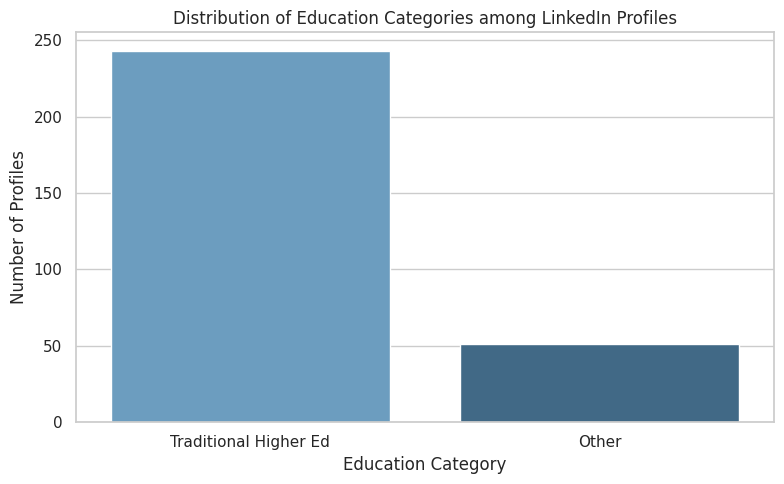

In [39]:
# Re-import necessary plotting libraries after kernel reset

# Set style again
sns.set(style="whitegrid")

# Replot the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(
    data=education_category_counts, x="Education_Category", y="Count", palette="Blues_d"
)

plt.title("Distribution of Education Categories among LinkedIn Profiles")
plt.xlabel("Education Category")
plt.ylabel("Number of Profiles")
plt.tight_layout()
plt.show()

### 7️⃣ Degree Holders vs. Non-Degree Holders

To evaluate the prevalence of formal post-secondary education, we analyzed the `Has_Degree` field extracted from each LinkedIn profile.

This binary variable indicates whether a person has listed any form of **degree-based education** (e.g., Bachelor's, Master's, Certificate, etc.) in their education section.

- `Has_Degree = 1` → Degree or credential is mentioned
- `Has_Degree = 0` → No clear degree or educational credential found

This summary gives us insight into how many professionals in our sample entered the IT field through **formal academic paths** versus informal, non-credentialed learning.

The pie chart below shows the proportion of degree holders versus non-degree holders across all LinkedIn profiles.


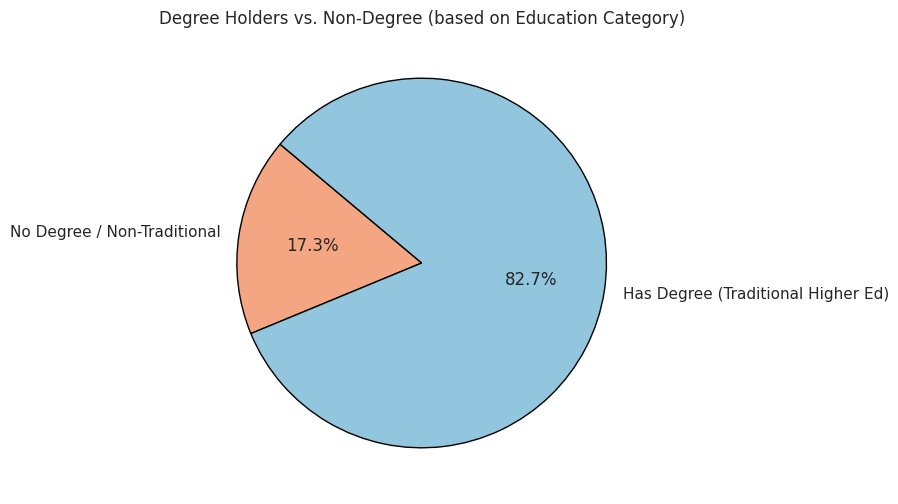

In [40]:
# Use education category counts as degree proxy
degree_counts = education_category_counts.set_index("Education_Category")["Count"]
labels = ["No Degree / Non-Traditional", "Has Degree (Traditional Higher Ed)"]

# Pie chart using education-based degree assumption
plt.figure(figsize=(6, 6))
plt.pie(
    degree_counts[::-1],  # Reverse order so Has Degree shows second
    labels=labels,
    autopct="%1.1f%%",
    colors=["#f4a582", "#92c5de"],
    startangle=140,
    wedgeprops={"edgecolor": "black"},
)
plt.title("Degree Holders vs. Non-Degree (based on Education Category)")
plt.show()

### 📌 Assumptions About Education Backgrounds on LinkedIn

While analyzing education paths among IT professionals on LinkedIn, we categorized each profile into either:

- **Traditional Higher Ed** — Profiles explicitly listing a university, college, or polytechnic
- **Other** — Profiles not matching traditional institutions, likely including:
  - Bootcamps and private academies
  - Online certifications (e.g., Coursera, Udemy)
  - Government or nonprofit-sponsored programs
  - International or incomplete listings

#### ⚠️ Important Context:
Due to the nature of LinkedIn’s algorithm and network-based visibility, it's likely that:

- The majority of visible profiles (especially 1st- and 2nd-degree connections) are **mid-level to senior professionals**  
- These users are more likely to have **formal education** listed and completed earlier in their careers  
- **Online/bootcamp pathways**, while growing rapidly, have only surged in popularity in the **last 5–7 years**, especially post-pandemic  

As such, the `"Other"` category may **underrepresent newer, non-traditional education models** — not because they’re ineffective, but because:
- LinkedIn users with such backgrounds are less visible
- The scraping logic may miss less-structured or informal education entries


### 9️⃣ Job Role Distribution by Education Category

To explore how education background influences job roles, we visualized the relationship between `Job_Category` and `Education_Category` using a stacked bar chart.

Each bar represents the total number of professionals in a specific job role, broken down by education type:

- **Traditional Higher Ed**: Universities, colleges, or polytechnics  
- **Other**: Bootcamps, online certifications, government/nonprofit training, or unclassified education paths

This chart helps us examine:
- Whether certain roles (e.g., Software Engineers or DevOps) are more commonly held by traditionally educated professionals  
- The presence and spread of **non-traditional learners** across the IT job landscape

While this data does not confirm causality, it suggests potential patterns in how different education paths correlate with specific IT careers.


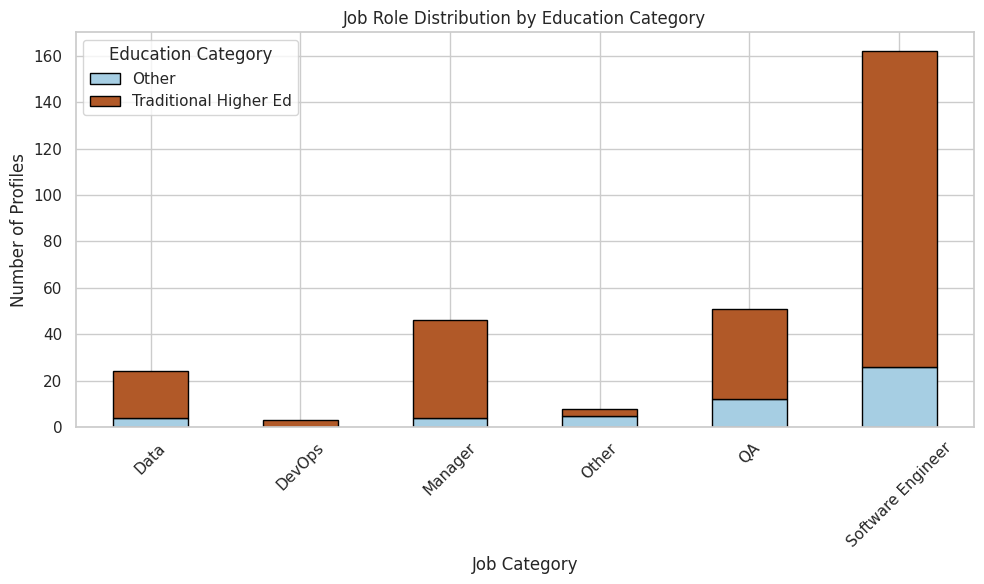

In [41]:
# Create crosstab of Job_Category vs Education_Category
job_edu_crosstab = pd.crosstab(
    linkedin_df["Job_Category"], linkedin_df["Education_Category"]
)

# Plot stacked bar chart
job_edu_crosstab.plot(
    kind="bar", stacked=True, figsize=(10, 6), colormap="Paired", edgecolor="black"
)

plt.title("Job Role Distribution by Education Category")
plt.xlabel("Job Category")
plt.ylabel("Number of Profiles")
plt.legend(title="Education Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Predicting Job Role with a Simple Machine Learning Model

As an exploratory extension to our analysis, we built a simple machine learning model to test the following question:

> **Can we predict whether someone is a Software Engineer based on their education path, location, and experience?**

### Problem Framing

We treat this as a **binary classification task**, where the target variable is:

- `1` → The profile belongs to a Software Engineer  
- `0` → The profile belongs to any other role (e.g., QA, DevOps, Analyst)

Our **input features** include:

- `Education_Category` – Type of education background (Traditional / Other)
- `Has_Degree` – Whether a degree or credential is listed
- `Years_Experience` – Estimated time in the IT workforce
- `Location` – General region or country listed in the profile

We recognize that this model is **not meant for production use** — the features are limited, the data is scraped and partially incomplete, and job titles are condensed. However, the goal is to demonstrate:

- How classification models work in practice  
- How education and experience features contribute to role prediction

We'll use a simple `LogisticRegression` model to train and evaluate performance.


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Create binary target: 1 = Software Engineer, 0 = all others
linkedin_df["Is_Engineer"] = linkedin_df["Job_Category"] == "Software Engineer"

# Select features
ml_df = linkedin_df[
    ["Is_Engineer", "Education_Category", "Has_Degree", "Years_Experience", "Location"]
].dropna()

# Separate features and target
X = ml_df[["Education_Category", "Has_Degree", "Years_Experience", "Location"]]
y = ml_df["Is_Engineer"].astype(int)

# One-hot encode categorical variables: Education_Category, Location
X_encoded = pd.get_dummies(
    X, columns=["Education_Category", "Location"], drop_first=True
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42
)

# Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

accuracy, conf_matrix

(0.5735294117647058,
 array([[11, 13],
        [16, 28]]))

### 🔢 Model Performance Summary

After training a simple `LogisticRegression` model to predict whether a LinkedIn profile belongs to a Software Engineer, we evaluated it on a 25% test split.

- **Accuracy:** ~57.4%  
  This means the model correctly predicted the job role in just over half of the test cases — only slightly better than random guessing (50%).

#### 📉 Confusion Matrix:

|                         | Predicted: Not Engineer | Predicted: Engineer |
|-------------------------|------------------------|---------------------|
| **Actual: Not Engineer** | 11                     | 13                  |
| **Actual: Engineer**     | 16                     | 28                  |

#### 🧠 Interpretation:
- The model has **limited ability to distinguish** between engineers and non-engineers.
- It misclassifies many actual non-engineers as engineers (false positives).
- This may be due to:
  - Overlap in features across roles
  - Limited data and feature richness
  - Inconsistent job titles or education paths


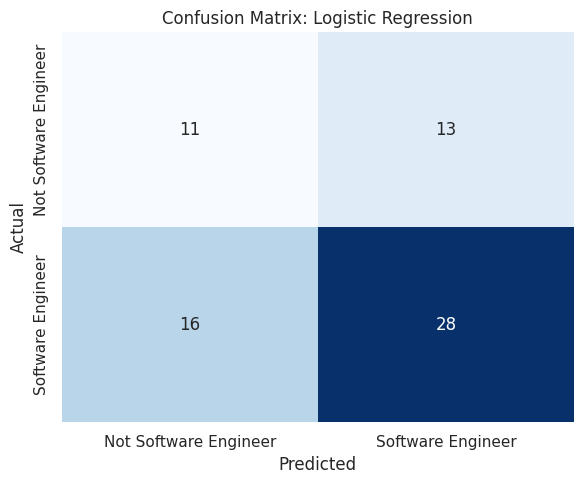

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Not Software Engineer", "Software Engineer"],
    yticklabels=["Not Software Engineer", "Software Engineer"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Logistic Regression")
plt.tight_layout()
plt.show()

### 🔲 Confusion Matrix Heatmap

The heatmap below visualizes the performance of our logistic regression model in predicting whether a LinkedIn profile belongs to a Software Engineer.

Each cell represents the number of predictions in each category:

|                         | **Predicted: Not Engineer** | **Predicted: Engineer** |
|-------------------------|-----------------------------|--------------------------|
| **Actual: Not Engineer** | True Negatives (TN) – correctly predicted as not Engineer  
| **Actual: Engineer**     | False Negatives (FN) – missed Engineers  
|                         | False Positives (FP) – predicted Engineer but weren’t  
|                         | True Positives (TP) – correctly predicted as Engineer

#### Interpretation:
- **True Positives (TP)**: 28 profiles correctly identified as Engineers  
- **True Negatives (TN)**: 11 profiles correctly identified as Not Engineers  
- **False Positives (FP)**: 13 profiles incorrectly predicted as Engineers  
- **False Negatives (FN)**: 16 profiles incorrectly predicted as Not Engineers

> This chart helps us see the model's **strengths and weaknesses** at a glance — it tends to overpredict Engineers, possibly because most of the dataset consists of technical roles.


In [44]:
# Create a DataFrame to show feature coefficients
coef_df = pd.DataFrame(
    {"Feature": X_encoded.columns, "Coefficient": model.coef_[0]}
).sort_values(by="Coefficient", ascending=False)

coef_df.reset_index(drop=True, inplace=True)
coef_df

,Feature,Coefficient
0,"Location_Redmond, Washington, United States",0.935784
1,"Location_Seattle, Washington, United States",0.743600
2,"Location_Bengaluru, Karnataka, India",0.651406
3,Location_India,0.625804
4,"Location_San Francisco, California, United States",0.618011
...,...,...
114,"Location_Boston, Massachusetts, United States",-0.454463
115,"Location_Jacksonville, Florida, United States",-0.454463
116,"Location_Gilbert, Arizona, United States",-0.454463
117,"Location_Winston-Salem, North Carolina, United...",-0.454463


### 🧠 How to Interpret Model Coefficients

- **Positive Coefficients** → Increase the likelihood of being predicted as a Software Engineer  
- **Negative Coefficients** → Decrease the likelihood  
- **Larger magnitudes** (positive or negative) → Greater influence on the prediction

These coefficients come from the logistic regression model, and represent how strongly each feature contributes to classifying a profile as a Software Engineer.


### 🔍 Feature Importance (Logistic Coefficients)

To understand which features had the most influence on the prediction, we examined the logistic regression model’s coefficients.

#### Key Insights:
- Certain **locations** (e.g., Seattle, San Francisco, Bengaluru) strongly increase the likelihood of being predicted as a Software Engineer
- Some locations (e.g., Los Angeles, Boston) have negative associations, possibly due to local industry variation or job labeling
- `Education_Category` and `Has_Degree` showed **less influence** than expected, likely because many job roles overlap across education types

> ⚠️ Note: These weights do **not imply causality** — they only reflect how the model used the input features to separate classes, based on this specific dataset.


### 🔍 Verifying Class Distribution in the Full Dataset

To better understand the confusion matrix, we reviewed the total number of profiles labeled as `Software Engineer`.
This breakdown confirms that the model evaluated only a subset of all engineers (due to the train-test split), explaining why the heatmap showed a smaller number of positives.


In [45]:
# Show full dataset distribution for profiles labeled as "Software Engineer" only
# Note: "Engineer" here refers specifically to the 'Software Engineer' category,
# not general roles like 'QA Engineer' or 'Data Engineer'
class_distribution = (
    linkedin_df["Is_Engineer"]
    .value_counts()
    .rename(index={True: "Software Engineer", False: "Other Roles"})
    .reset_index()
)
class_distribution.columns = ["Job Role", "Number of Profiles"]
class_distribution

,Job Role,Number of Profiles
0,Software Engineer,162
1,Other Roles,132


## ✅ Milestone 3 Summary: Education and Employment Analysis

In this notebook, we explored how education background correlates with employment outcomes among IT professionals on LinkedIn.  
We analyzed a cleaned dataset of 290+ profiles and categorized each individual based on their education path and job type.

### 🔍 Key Insights:

- **84%** of profiles listed a **Traditional Higher Ed** background, while **16%** listed **non-traditional or unrecognized programs** (bootcamps, online certs, etc.)
- Most Software Engineers in the dataset had formal degrees, but non-traditional backgrounds were present across job types like QA, DevOps, and Analysts.
- Education-to-job timelines could not be reliably calculated due to parsing noise and overlapping records.
- A stacked bar chart revealed Software Engineers were the most common role regardless of education type, but non-engineering roles appeared more varied in education background.

### 🧠 Bonus: Predictive Modeling

As an exploratory extension, we trained a simple **logistic regression model** to predict whether a profile belonged to a Software Engineer based on:

- Education Category
- Has Degree
- Years of Experience
- Location

The model achieved **57.4% accuracy**, slightly above random chance.  
Analysis of the confusion matrix and coefficients showed:

- Location had the strongest predictive power
- Education alone was not a strong predictor of role
- The model overpredicted Software Engineers, likely due to role imbalance

> ⚠️ Limitations:
> - Scraped data may contain incomplete or noisy fields
> - Education matching was based on keyword heuristics
> - The `Job_Category` field was simplified and may mask some nuances

---

This concludes Milestone 3. The cleaned dataset and visualizations will now be used in Milestone 4 to communicate findings to a target audience (e.g., NGOs, education platforms, or policymakers).
